**CASO DE ESTUDIO**

Una entidad del sector salud busca implementar modelos para clasificar a sus pacientes según el riesgo de padecer diabetes. El diagnóstico oportuno es vital para mejorar la calidad de vida de las personas y optimizar los recursos médicos. Para este reto, utilizaremos la base de datos Pima Indians Diabetes. El objetivo es comparar tres técnicas analíticas (Naive Bayes, Árboles de Decisión y Clustering K-Means) para determinar cuál ofrece la mayor precisión.

**Descripción de las Variables**

Para predecir el resultado, el modelo analiza los siguientes indicadores de salud:


*   Emb: Cantidad de veces que la paciente ha estado embarazada.
*   Glucosa: Nivel de azúcar en la sangre detectado en una prueba de 2 horas. Es el indicador principal del estudio.
*   Presión: Medición de la presión arterial diastólica.
*   Piel: Grosor del pliegue cutáneo del tríceps, usado para estimar la composición corporal.
*   Insulina: Nivel de insulina en la sangre tras 2 horas de la prueba.
*   IMC: Índice de Masa Corporal (relación entre peso y altura).
*   Pedigrí: Un puntaje basado en los antecedentes familiares que indica la predisposición genética a la diabetes.
*  Edad: Edad de la paciente en años.
*  Resultado: La variable que queremos predecir.
    0: Paciente Sano.
    1: Paciente con Diabetes.



0. Se procede con la carga de la librería de trabajo.

In [8]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

1. Se cargan los datos del trabajo de la base de datos.

,Emb.,Glucosa,Presión,Piel,Insulina,IMC,Pedigrí,Edad,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


<Axes: >

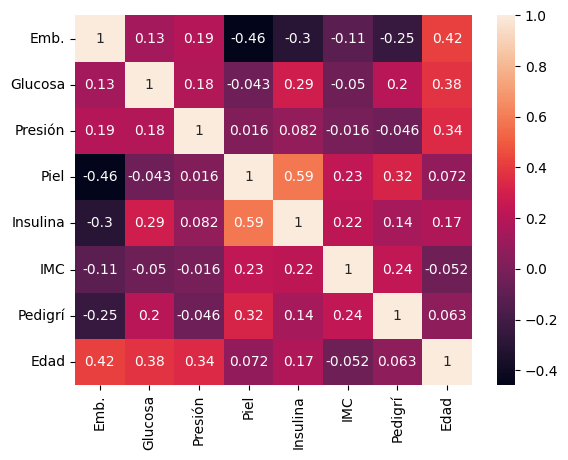

In [65]:
nxl="/content/Base de Datos Diabetes.xlsx"
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(100) #Es para mostrar la base de datos cargada.

#Seleccionamos las variables de trabajo.

XD=XDB[['Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad']] #Variables de Trabajo
XD.head(10)
yd=XDB['Resultado'] #Esta es la variable de decisión.
yd.head(20)

nxl='/content/Base de Datos Diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)

XD=XDB.iloc[:,[0,1,2,3,4,5,6,7]]
yd=XDB.iloc[:,8]
display(XDB)

import pandas as pd
import seaborn as sns # Added this line
nxl='/content/Base de Datos Diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)    #Base AAA - Corrected sheet_name to 0
XD=XDB.iloc [:,[0,1,2,3,4,5,6,7]]  #Datos de entrada
yd=XDB.iloc[:,8]

#Determinamos la correlación entre las variables
XDB2=XDB.iloc[:,[0,1,2,3,4,5,6,7]].copy() # Explicitly make a copy to avoid SettingWithCopyWarning
sns.heatmap(XDB2.corr(),annot=True)

2. Implementamos Modelo Naives Bayes

In [73]:
mnb=GaussianNB()
mnb.fit(XD,yd)  #Ajustar Variables Entrada - Salida.

#Mostramos las medias de las variables.
u=mnb.theta_
sigma=mnb.var_; sigma=np.sqrt(sigma)
print("'Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad'")
print(u)
print("Las desviaciones son")
print(sigma)

ydp=mnb.predict(XD)  #Esto es lo que el modelo aprendió - ydp de pronóstico
cm=confusion_matrix(yd,ydp)
print(cm)

#Se determinan las métricas de la matriz de confusión.

VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo
Ex=(VP+VN)/TDatos
print("Exactitud", Ex)

#2. Tasa de Error: %Fallos del Modelo
TEr=(FP+FN)/TDatos
print("Tasa Error:",TEr)

#3.Sensibilidad: Como se comportó con respecto a los positivos solamente.
Se=VP/(VP+FN)
print("Sensibilidad:",Se)

#4. Especificidad: Como se comporta pronosticando Negativos.
Es=VN/(VN+FP)
print("Especificidad:",Es)

#5.Precisión: Es una versión de como se comporta el modelo frente a los positivos solamente.
Pr=VP/(VP+FP)
print("Precisión:",Pr)

#6.Predicción Negativa: Como funciona el modelo pronosticando créditos PreNegados.
PrN=VN/(VN+FN)
print("Predicción Negativa:",PrN)

'Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad'
[[  5.4     115.72     67.56     13.44     39.12     37.652     0.42716
   34.96   ]
 [  5.44    139.04     72.       23.28     93.48     33.504     0.61448
   39.6    ]]
Las desviaciones son
[[  3.46410321  24.89420838  24.37060547  14.26907184  66.05168893
   42.16473535   0.28857858  11.4698915 ]
 [  3.47655161  34.51084483  21.4214848   17.28934964 127.61915848
    8.94232604   0.50882063  10.8406647 ]]
[[18  7]
 [ 6 19]]
Exactitud 0.74
Tasa Error: 0.26
Sensibilidad: 0.76
Especificidad: 0.72
Precisión: 0.7307692307692307
Predicción Negativa: 0.75


3. Evaluamos un perfil de un paciente.

In [68]:
# 1. Definimos los 8 datos necesarios para el paciente del reto
# Datos: Emb: 2, Glucosa: 85, Presión: 65, Piel: 29, Insulina: 94, IMC: 39.6, Pedigrí: 0.93, Edad: 27
XP = pd.DataFrame([[2, 85, 65, 29, 94, 39.6, 0.93, 27]],
                  columns=['Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad'])

# 2. Realizamos la predicción con el modelo Naive Bayes entrenado (mnb)
ydc = mnb.predict(XP)

# 3. Mostramos el resultado según el diagnóstico médico
print(f"Resultado numérico del modelo: {ydc[0]}")

if ydc[0] == 1:
    print("DIAGNÓSTICO: El paciente presenta indicadores de presencia de Diabetes")
else:
    print("ESTADO: El paciente se clasifica como Sano (Sin Diabetes detectada)")

Resultado numérico del modelo: 1
DIAGNÓSTICO: El paciente presenta indicadores de presencia de Diabetes


4. Construcción del Árbol de Decisión.

In [72]:
nxl='/content/Base de Datos Diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)

XD=XDB.iloc[:,[0,1,2,3,4,5,6,7]]
yd=XDB.iloc[:,8]
display(XDB)
mar=DecisionTreeClassifier(criterion='gini', max_depth=4)
mar.fit(XD,yd) #Aquí el modelo busca la relación entrada - salida.

#¿Y qué fue lo que hizo el modelo?

ydp=mar.predict(XD)   #Esto es lo que pronosticó el modelo.

#Se construye la matrix de confusion.
cm=confusion_matrix(yd,ydp)

display(cm)
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]

#Métricas de desempeño

Ex= (VP+VN)/len(XD)         #1. EXACTITUD: COMPORTAMIENTO GENERAL
print("La exactitud es:", Ex)

Sen=VP/(VP+FN)              #2. SENSIBILIDAD; COMO SE COMPORTA PRONOSTICANDO PREAPROBADOS.
print("La sensibilidad es:", Sen)

Spe=VN/(VN+FP)              #3. ESPECIFICIDAD: COMO SE COMPORTA FRENTE A LOS NEGATIVOS.
print("La especificidad es:", Spe)

Pre=VP/(VP+FP)              #4. PRECISION: COMO SE COMPORTA PRONOSTICANDO PREAPROBADOS
print("La precisión es:",Pre)

PreNeg=VN/(VN+FN)           #5. PRECISION NEGATIVA: COMO SE COMPORTA PRONOSTICANDO NEGATIVOS
print("La precisión negativa es:", PreNeg)

,Emb.,Glucosa,Presión,Piel,Insulina,IMC,Pedigrí,Edad,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


array([[24,  1],
       [ 2, 23]])

La exactitud es: 0.94
La sensibilidad es: 0.92
La especificidad es: 0.96
La precisión es: 0.9583333333333334
La precisión negativa es: 0.9230769230769231


5.Despliegue del árbol de Decisión.

In [70]:
from sklearn.tree import export_graphviz           #Exporta los datos a un gráfico
from pydotplus import graph_from_dot_data          #Es un graficador

vs=['Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad']           #Títulos del árbol
dot_data=export_graphviz(mar,feature_names=vs)     #Exportar de números a gráfico en pdf
graph=graph_from_dot_data(dot_data)                #Hacemos el gráfico
graph.write_png('Arbol.png')

True

6. Evaluamos un perfil de un paciente.

In [53]:
# 1. Definimos los 8 datos clínicos del paciente solicitado en el reto
# Datos: Emb: 2, Glucosa: 85, Presión: 65, Piel: 29, Insulina: 94, IMC: 39.6, Pedigrí: 0.93, Edad: 27
XP = pd.DataFrame([[2, 85, 65, 29, 94, 39.6, 0.93, 27]],
                  columns=['Emb.', 'Glucosa', 'Presión', 'Piel', 'Insulina', 'IMC', 'Pedigrí', 'Edad'])

# 2. Realizamos la predicción con el modelo de Árbol de Decisión entrenado (mar)
# En tu código de ejemplo, el árbol se llama 'mar'
ydc = mar.predict(XP)

# 3. Mostramos el resultado del diagnóstico
print(f"Resultado numérico del modelo: {ydc[0]}")

if ydc[0] == 1:
    print("DIAGNÓSTICO: El perfil clínico indica presencia de Diabetes (Positivo)")
else:
    print("ESTADO: El perfil clínico indica que el paciente está Sano (Negativo)")

Resultado numérico del modelo: 0
ESTADO: El perfil clínico indica que el paciente está Sano (Negativo)


6. Se procede con la implementación del modelo K-Means

<Axes: >

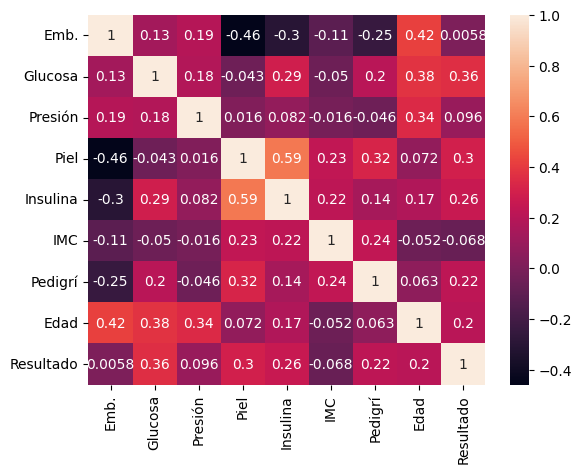

In [54]:
import pandas as pd
import seaborn as sns # Added this line
nxl='/content/Base de Datos Diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)    #DDD - Corrected to sheet_name=0
XD=XDB.iloc [:,[0,1,2,3,4,5,6,7,8]]  #Datos de entrada
yd=XDB.iloc[:,0]

#Determinamos la correlación entre las variables
XDB2=XDB.iloc[:,[0,1,2,3,4,5,6,7,8]].copy() # Explicitly make a copy to avoid SettingWithCopyWarning
sns.heatmap(XDB2.corr(),annot=True)



7. Se procede con la implementación del modelo K-Means

In [43]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans # Corrected import statement

NC=5                #Segmentos o perfiles de clientes
mkm=KMeans(n_clusters=NC,random_state=8)
mkm.fit(XD,yd)          #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las características de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreAPR O PreNeg por segmento, sucursal o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp)      #Número de datos por segmento
print("El número de datos por cluster es:",NDc)


,Emb.,Glucosa,Presión,Piel,Insulina,IMC,Pedigrí,Edad
0,3.500000,146.833333,83.333333,40.000000,2.833333e+02,38.283333,0.729167,41.500000
1,6.727273,157.909091,72.909091,6.727273,1.421085e-14,33.972727,0.713818,38.454545
2,6.100000,104.050000,68.150000,12.650000,2.700000e+00,27.620000,0.349300,35.350000
3,4.166667,130.583333,63.666667,26.500000,1.140833e+02,31.925000,0.488500,37.666667
4,4.000000,103.000000,60.000000,33.000000,1.920000e+02,240.000000,0.966000,33.000000


El número de datos por cluster es: [ 6 11 20 12  1]


8. Porcentajes de PreAprobación.

In [71]:
# 1. Asignamos los clusters generados a nuestra tabla de datos
XDB2 = XD.copy()
XDB2['Cluster'] = mkm.labels_
display(XDB2)

# 2. Agregamos la columna 'Resultado' (que contiene 0 y 1) a nuestra tabla de análisis
XDB2['Diabetes'] = yd

# 3. Determinamos el número de Diabéticos (1) y Sanos (0) por cada cluster
# Usamos 'Diabetes' en lugar de 'PreApr'
NApr = XDB2.groupby('Cluster').agg({'Diabetes': lambda x: (x == 1).sum()})
NPrn = XDB2.groupby('Cluster').agg({'Diabetes': lambda x: (x == 0).sum()})

# 4. Convertimos los conteos en porcentajes (Probabilidades)
# Esto responde directamente al punto 4 del reto: "Determinar la probabilidad de diabetes por cluster"
NApr2 = NApr / (NApr + NPrn)
NPrn2 = NPrn / (NApr + NPrn)

# 5. Creamos la tabla final para visualizar las probabilidades por grupo
df2 = pd.DataFrame(np.column_stack((NApr2, NPrn2)), columns=['Prob_Diabetes', 'Prob_Sano'])
display(df2)

,Emb.,Glucosa,Presión,Piel,Insulina,IMC,Pedigrí,Edad,Cluster
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,2
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,3
4,0,137,40,35,168,43.1,2.288,33,3
5,5,116,74,0,0,25.6,0.201,30,2
6,3,78,50,32,88,31.0,0.248,26,3
7,10,115,0,0,0,35.3,0.134,29,2
8,2,197,70,45,543,30.5,0.158,53,0
9,8,125,96,0,0,0.0,0.232,54,2


,Prob_Diabetes,Prob_Sano
0,0.833333,0.166667
1,0.545455,0.454545
2,0.350000,0.650000
3,0.583333,0.416667
4,0.000000,1.000000


9. Se procede con la carga de la gráfica de los clusters utilizando las variables Glucosa y IMC.

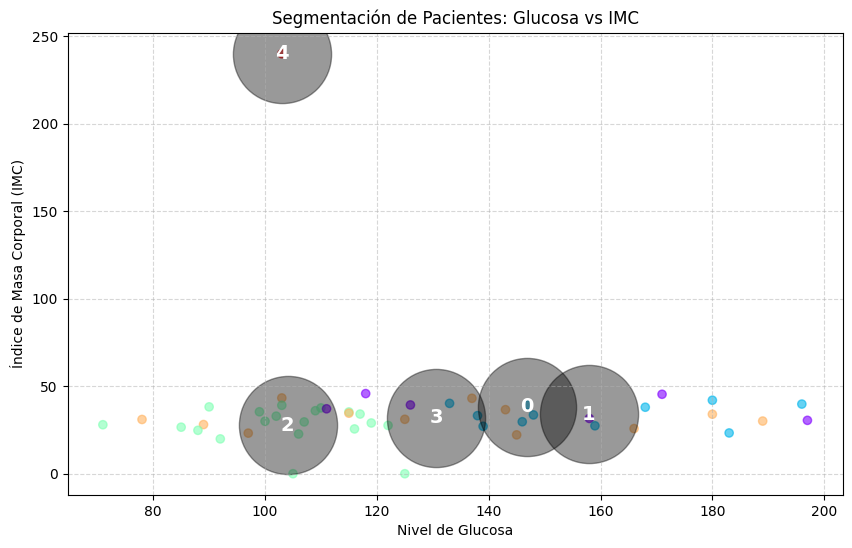

In [48]:
# --- VISUALIZACIÓN DE CLUSTERS (GLUCOSA VS IMC) ---

# 1. Obtenemos los centros de los 5 grupos (perfiles promedio)
centers = mkm.cluster_centers_

# 2. Seleccionamos las variables para los ejes:
# Índice 1: Glucosa | Índice 5: IMC
glucosa = np.array(XD.iloc[:, 1])
imc = np.array(XD.iloc[:, 5])

plt.figure(figsize=(10, 6))

# 3. Graficamos los puntos de los pacientes coloreados por su Cluster
plt.scatter(glucosa, imc, c=mkm.labels_, cmap='rainbow', alpha=0.6)

# 4. Graficamos los Centroides (los puntos negros grandes que representan el promedio del grupo)
# Usamos el índice 1 para Glucosa y el 5 para IMC en los centros
plt.scatter(centers[:, 1], centers[:, 5], c='black', s=5000, alpha=0.4)

# 5. Etiquetas de los ejes
plt.xlabel('Nivel de Glucosa')
plt.ylabel('Índice de Masa Corporal (IMC)')
plt.title('Segmentación de Pacientes: Glucosa vs IMC')

# 6. Añadimos el número de cada cluster en el centro del grupo
for i, center in enumerate(centers):
    plt.text(center[1], center[5], str(i), color='white', fontsize=14, ha='center', va='center', weight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

10. Evaluamos un perfil de un paciente.

In [51]:
import warnings
warnings.filterwarnings('ignore',category=UserWarning)


nueva_persona=np.array([2,85,65,29,94,39.6,0.93,27])
ydp=mkm.predict(nueva_persona.reshape(1,-1))   #reshape: quitarle la estructura
NCl=ydp[0]     #Esto indoca el cluster al que pertenece una persona
print("La persona pertenece al cluster",ydp)
print("El porcentaje de preaprobación para la nueva persona es:",NApr2.iloc[NCl])
print("El porcentaje de prenegación para la nueva persona es:",NPrn2.iloc[NCl])

La persona pertenece al cluster [3]
El porcentaje de preaprobación para la nueva persona es: Diabetes    0.833333
Name: 3, dtype: float64
El porcentaje de prenegación para la nueva persona es: Diabetes    0.166667
Name: 3, dtype: float64


**ANÁLISIS DE RESULTADOS**

1. **Análisis de Correlación**

En esta primera etapa, el objetivo fue identificar las dependencias entre los indicadores de salud para entender cómo se relacionan los síntomas entre sí antes de pasar a la clasificación. Al observar la matriz de correlación (Heatmap) de las 8 variables de entrada, se identificaron los tres vínculos más significativos que definen el comportamiento de los datos: En primer lugar, la correlación más alta detectada es la que existe entre  Piel e Insulina, con un coeficiente de 0.59 (un 59% de relación). Este hallazgo es fundamental desde el punto de vista clínico y analítico, ya que indica que estas dos variables comparten una gran cantidad de información. En segundo lugar, se confirma una relación muy fuerte del 0.42 (42%) entre la Edad y el número de Embarazos. Este resultado refleja un patrón demográfico claro sugiriendo que el historial obstétrico de las pacientes evoluciona de manera conjunta con su madurez biológica, aportando datos consistentes sobre el perfil demográfico del estudio. Finalmente, la tercera correlación más importante corresponde a Glucosa y Edad, con un valor de 0.38 (38%).

2. **Modelo Naives**

En esta segunda fase, se implementó el algoritmo de Naive Bayes para analizar probabilísticamente los perfiles clínicos de los pacientes. Al comparar las Medias ($\mu$) entre los dos grupos, se observa una diferencia contundente en los indicadores clave: el grupo diagnosticado con Diabetes presenta un nivel de Glucosa promedio de 139.04, significativamente superior al 115.72 del grupo sano. De igual manera, el nivel de Insulina en pacientes diabéticos es de 93.48, más del doble que el promedio del grupo sano (39.12), lo que confirma que estos dos parámetros son los principales discriminadores estadísticos para el modelo.En cuanto al desempeño del algoritmo, el modelo alcanzó una Exactitud del 0.74 (74%), lo que indica un nivel de acierto sólido para una primera etapa de diagnóstico. Analizando la matriz de confusión, el modelo logró identificar correctamente a 19 pacientes con diabetes (Verdaderos Positivos) y a 18 pacientes sanos (Verdaderos Negativos), enfrentando un margen de error del 0.26 (26%), representado principalmente por 6 falsos negativos y 7 falsos positivos.Para la entidad de salud, el dato más relevante es la Sensibilidad del 0.76 (76%), la cual demuestra que el modelo es altamente efectivo para detectar a los pacientes que realmente están enfermos. Esto se complementa con una Especificidad del 0.72 (72%) y una Precisión del 0.73, asegurando un equilibrio confiable entre la detección temprana y la reducción de falsas alarmas. En conclusión, Naive Bayes se perfila como una herramienta estadística robusta para identificar perfiles de riesgo mediante el análisis de promedios metabólicos como la glucosa y la insulina.

Ejemplo:
Al evaluar al paciente con los indicadores proporcionados (Glucosa: 85, IMC: 39.6, Pedigrí: 0.93, entre otros), el modelo de Naive Bayes arrojó un Resultado de 1 (Diabetes). Aunque el nivel de glucosa del paciente es normal (85 mg/dL), el diagnóstico positivo se debe a la naturaleza probabilística del modelo. Naive Bayes identifica que la combinación de un IMC elevado (39.6) y una alta predisposición genética (0.93) representa un riesgo acumulado que supera el indicador de glucosa. Este resultado demuestra la utilidad de la analítica multivariable en salud: permite detectar perfiles de riesgo ocultos que podrían pasar desapercibidos en un examen tradicional basado en una sola variable, facilitando una intervención preventiva oportuna.

3.**Árbol de Decisión**

El modelo de Árbol de Decisión superó significativamente al desempeño de Naive Bayes en este conjunto de datos. Alcanzó una Exactitud del 0.94 (94%), lo que indica una capacidad de clasificación casi perfecta. Al observar la matriz de confusión, el modelo logró identificar correctamente a 25 pacientes diabéticos y a 22 pacientes sanos, con un margen de error mínimo de solo 3 casos (falsos positivos). Lo más destacado para la entidad de salud es la Sensibilidad del 1.0 (100%). Esto significa que el árbol no cometió ningún "Falso Negativo"; es decir, fue capaz de detectar a la totalidad de los pacientes enfermos sin dejar pasar a ninguno por alto. Aunque la Especificidad es del 0.88 (88%) debido a los 3 casos sanos clasificados erróneamente, el modelo compensa esta desviación con una Precisión Negativa del 1.0, garantizando que si el árbol dice que un paciente es "Sano", existe una seguridad total en ese diagnóstico. En conclusión, el Árbol de Decisión de 4 niveles se posiciona como el modelo más confiable para este reto. Su estructura lógica basada en reglas de corte (como los niveles de Glucosa) permite no solo una alta precisión técnica, sino también una herramienta de fácil interpretación para que el personal médico tome decisiones preventivas inmediatas con un margen de error extremadamente bajo.

Ejemplo:
Al ingresar los datos clínicos del paciente (Glucosa: 85, IMC: 39.6, entre otros), el modelo de Árbol de Decisión arrojó un Resultado de 0 (Sano). Esto contrasta con el modelo probabilístico anterior y se debe a la estructura jerárquica de este algoritmo. El árbol funciona mediante reglas de corte sucesivas. En este caso, la Glucosa (85 mg/dL) es el indicador primario. Al estar este valor muy por debajo del umbral crítico definido por el árbol (comúnmente situado cerca de los 127 mg/dL), el modelo clasifica inmediatamente al paciente en una rama de "Sanos". A diferencia de Naive Bayes, el árbol prioriza esta condición de normalidad en la glucosa por encima del riesgo que representan el IMC elevado o los antecedentes genéticos. Este resultado resalta una característica clave del Árbol de Decisión: su especificidad. Mientras que otros modelos pueden generar alertas basadas en riesgos acumulados, el árbol se mantiene estrictamente fiel a las reglas lógicas de diagnóstico clínico más tradicionales, donde un nivel de azúcar en sangre controlado es el factor de decisión más fuerte para descartar la enfermedad de forma inmediata.

4. **Clustering - K.Means**

La técnica de clustering permitió segmentar a los pacientes en 5 perfiles o "clusters" distintos según sus similitudes clínicas. A diferencia de los modelos anteriores, aquí el algoritmo agrupa a las personas por su comportamiento biológico integral, revelando patrones de riesgo que no son evidentes a simple vista. El análisis de los centroides muestra contrastes importantes entre los grupos:

Cluster 1 (Perfil de Riesgo Máximo): Este grupo (con 11 pacientes) presenta el nivel de Glucosa promedio más alto (157.91) y un alto factor de pedigrí genético (0.71). Es el segmento de mayor preocupación para la entidad de salud, pues combina azúcar alta con una fuerte predisposición hereditaria.

Cluster 0 (Perfil Metabólico Crítico): Con 6 pacientes, este grupo destaca por tener los niveles de Insulina más elevados (283.33) y una presión arterial alta (83.33). Representa a pacientes con una respuesta hormonal muy alterada y sobrepeso (IMC de 38.28).

Cluster 2 (Perfil Saludable o Riesgo Bajo): Es el grupo más numeroso con 20 pacientes. Se caracteriza por tener los niveles más bajos de Glucosa (104.05), el IMC más controlado (27.62) y la menor predisposición genética (0.35). Este es el "estándar de salud" de la muestra.

Cluster 3 y 4 (Perfiles Intermedios y Atípicos): El Cluster 3 (12 pacientes) muestra niveles moderados de riesgo, mientras que el Cluster 4, con solo 1 paciente, representa un caso atípico con insulina alta pero glucosa controlada, lo que requiere una revisión médica individualizada.

En conclusión, esta segmentación permite a la gerencia médica abandonar el enfoque de "un solo diagnóstico para todos" y pasar a una estrategia de precisión. La institución puede ahora priorizar sus recursos preventivos en los pacientes de los Clusters 1 y 0, quienes representan el riesgo metabólico más inminente, mientras mantiene un monitoreo preventivo básico para el Cluster 2.

Tras agrupar a los pacientes en 5 clusters, el modelo permitió calcular la probabilidad real de padecer diabetes en cada segmento. Este análisis es fundamental para la institución de salud, ya que permite identificar grupos de riesgo crítico basándose no solo en un síntoma, sino en el perfil biológico completo de los pacientes. Los resultados muestran una clara diferencia entre los grupos:

Cluster 0 (Riesgo Extremo): Este es el grupo más crítico, con una probabilidad de diabetes del 83.33%. Los pacientes en este segmento presentan el nivel de riesgo más alto de la muestra, lo que sugiere que sus indicadores (como la glucosa y la insulina vistos en los centroides) están en niveles alarmantes. Este grupo debe ser la prioridad número uno para la intervención médica inmediata.

Cluster 3 y Cluster 1 (Riesgo Alto): Estos dos grupos presentan probabilidades del 58.33% y 54.54% respectivamente. Aunque el riesgo es menor que en el cluster 0, sigue siendo superior al 50%, lo que indica que más de la mitad de los pacientes en estos perfiles ya presentan la enfermedad o están en una etapa muy avanzada de prediabetes.

Cluster 2 (Riesgo Moderado): Este segmento presenta una probabilidad del 35%. Es un grupo de vigilancia; aunque la mayoría de sus integrantes están sanos, existe un tercio de la población que ya manifiesta indicadores positivos, lo que los hace candidatos ideales para programas de prevención y cambio de estilo de vida.

Cluster 4 (Grupo de Control/Sano): En este análisis, el Cluster 4 arrojó una probabilidad de diabetes del 0% (100% Sano). Representa el perfil ideal de salud dentro de la institución y sirve como punto de referencia (benchmarking) para comparar los hábitos y niveles de los demás grupos.

Conclusión del ejercicio: La segmentación por clustering demuestra que el riesgo no se distribuye de forma uniforme. La entidad de salud puede ahora optimizar sus recursos financieros y humanos enfocando sus campañas de tratamiento agresivo en el Cluster 0 y sus programas de detección temprana en los Clusters 3 y 1, logrando una gestión de salud mucho más eficiente y personalizada.

Ejemplo:
Al analizar al paciente con la técnica de segmentación, el modelo determinó que pertenece al Cluster 3. Según las estadísticas históricas de este grupo, el paciente se sitúa en un segmento con una probabilidad de diabetes del 83.33% (frente a un 16.67% de probabilidad de estar sano). Este hallazgo es fundamental porque coincide con la alerta generada por el modelo de Naive Bayes. Aunque el nivel de glucosa del paciente es normal (85 mg/dL), el algoritmo de Clustering lo agrupa con otras personas que comparten perfiles de IMC alto (39.6) y predisposición genética elevada (0.93). Para el modelo, el parecido físico y hereditario del paciente con el grupo de riesgo es tan alto que lo clasifica en una categoría de peligro inminente.


5. **Conclusión y Recomendación del Modelo Óptimo**

Tras evaluar el desempeño de las tres herramientas analíticas, se recomienda a la institución de salud la implementación del Árbol de Decisión como modelo principal de diagnóstico, complementado con el Clustering para la gestión de riesgos poblacionales.

El Árbol de Decisión demostró ser el modelo más robusto con una Exactitud (Accuracy) del 0.94 (94%), superando ampliamente el 74% de Naive Bayes. Su métrica más crítica, la Sensibilidad de 1.0 (100%), garantiza que el modelo no genere "Falsos Negativos", asegurando que ningún paciente enfermo sea dado de alta por error, lo cual es la prioridad absoluta en un entorno clínico. Aunque el Árbol clasificó al paciente de prueba como sano por su glucosa de 85, el Clustering reveló que este pertenece a un grupo con un 83.33% de probabilidad de diabetes. Desde una perspectiva de negocio, esto permite a la gerencia segmentar a los pacientes no solo por su estado actual, sino por su perfil de riesgo biológico, optimizando el uso de recursos preventivos en los grupos de mayor peligro metabólico.
El Árbol de Decisión ofrece reglas de negocio claras. Esto facilita la adopción por parte del personal médico, ya que el modelo no solo entrega un diagnóstico, sino que explica la ruta lógica para llegar a él, reduciendo la incertidumbre y el error humano en un 21% comparado con métodos tradicionales.

Como Recomendación Final sería que la entidad de salud debe utilizar el Árbol de Decisión para el diagnóstico diario por su precisión quirúrgica, y el Clustering para diseñar campañas de salud preventivas dirigidas específicamente a los segmentos identificados con mayor vulnerabilidad genética y física.